```28/07/2025 - Gabriel A. Amici```

# Implementando classes para a biblioteca ```emerald```

### Objetivos:
- Compactar código
- Reutilizar rotinas similares
- Facilitar uso da biblioteca

### Classes base:
- ```Potential```
- ```Field```
- ```Particle```
- ```System```

In [38]:
import numpy as np
import warnings
from scipy.optimize import brentq

In [39]:
# to be added to its own module later

from scipy.special import roots_legendre


def gauss_legendre_quadrature(func: callable, a: float, b: float, N: int) -> float:
    """
    Gauss-Legendre Quadrature for numerical integration.

    Parameters:
    func : callable
        The function to integrate.
    a : float
        The lower limit of integration.
    b : float
        The upper limit of integration.
    N : int
        The number of quadrature points (degree of the Legendre polynomial).
    """

    # Compute the roots and weights for the N-th degree Legendre polynomial
    roots, weights = roots_legendre(N)
    
    # Transform the roots to the interval [a, b]
    transformed_roots = 0.5 * (b - a) * roots + 0.5 * (b + a)
    
    # Evaluate the function at the transformed roots
    func_values = func(transformed_roots)
    
    # Compute the quadrature result
    result = 0.5 * (b - a) * np.dot(weights, func_values)
    
    return result

def simpson13(func: callable, a: float, b: float, dx: float = 1.e-5):
    """
    General Simpson 1/3 quadrature for callable `func`

    Parameters:
        func : callable
            The function to integrate.
        a : float
            The lower limit of integration.
        b : float
            The upper limit of integration.
        dx : int
            The extent of each interval.
    """
    n = round((b - a) / dx)
    n += 1 if (n % 2 != 0) else 0

    if n % 2 != 0:
        raise ValueError(
            "Simpson's 1/3 rule requires an even number of intervals."
        )

    # x = a + np.arange(n + 1) * dx
    # x = np.arange(a, b+dx, dx)
    x = np.linspace(a, b, n)
    y = func(x)

    return (dx / 3) * (
        y[0]
        + y[-1]
        + 4 * np.sum(y[1:-1:2])
        + 2 * np.sum(y[2:-1:2])
    )

In [126]:


# class Potential:
#     """
#     Base class for 1D potentials, responsible for calculating the potential 
#     and its derivatives, as well as the classical return points.
#     """

#     def __init__(self, *args, **kwargs):
#         self.name    = None
#         self.acronym = None

#     def __call__(self, positions):
#         return self.value(positions)
    
#     def value(self, positions):
#         """
#         Potential evaluated at a range of positions

#         Parameters
#         ----------
#         positions : array-like
#             Array of positions at which to evaluate the potential

#         Returns
#         -------
#         potential_values : array-like
#             Array of potential values corresponding to the input positions
#         """
#         r = np.asarray(positions)
#         pass
    
#     def first_derivative(self, positions):
#         """
#         1st derivative of the potential evaluated for a range of positions

#         Parameters
#         ----------
#         positions : array-like
#             Array of positions at which to evaluate the derivative

#         Returns
#         -------
#         first_derivative_values : array-like
#             Array of first derivative values corresponding to the input positions
#         """
#         r = np.asarray(positions)
#         pass
    
#     def second_derivative(self, positions):
#         """
#         2nd derivative of the potential evaluated for a range of positions

#         Parameters
#         ----------
#         positions : array-like
#             Array of positions at which to evaluate the second derivative

#         Returns
#         -------
#         second_derivative_values : array-like
#             Array of second derivative values corresponding to the input positions
#         """
#         r = np.asarray(positions)
#         pass
    
#     def return_points(self):
#         """Classical return points of the potential"""
#         pass

from abc import ABC, abstractmethod


class Potential(ABC):
    """
    Base class for 1D potentials, responsible for calculating the potential 
    and its derivatives, as well as the classical return points.
    """

    def __init__(self, *args, **kwargs):
        self.name    = kwargs.get('name') if 'name' in kwargs else None
        self.acronym = kwargs.get('acronym') if 'acronym' in kwargs else None
        self.symmetric = self._check_symmetry()

    def __call__(self, r):
        return self.value(r)

    @abstractmethod
    def value(self, position_array):
        """
        Potential evaluated at a range of positions

        Parameters
        ----------
        position_array : array-like
            Array of positions at which to evaluate the potential

        Returns
        -------
        potential_values : array-like
            Array of potential values corresponding to the input positions
        """
        r = np.asarray(position_array)
        pass

    @abstractmethod
    def first_derivative(self, position_array):
        """
        1st derivative of the potential evaluated for a range of positions

        Parameters
        ----------
        position_array : array-like
            Array of positions at which to evaluate the derivative

        Returns
        -------
        first_derivative_values : array-like
            Array of first derivative values corresponding to the input positions
        """
        r = np.asarray(position_array)
        pass

    @abstractmethod
    def second_derivative(self, position_array):
        """
        2nd derivative of the potential evaluated for a range of positions

        Parameters
        ----------
        position_array : array-like
            Array of positions at which to evaluate the second derivative

        Returns
        -------
        second_derivative_values : array-like
            Array of second derivative values corresponding to the input positions
        """
        r = np.asarray(position_array)

    def _check_symmetry(self):
        """
        Check if the potential is symmetric around the origin

        Returns
        -------
        bool
            True if the potential is symmetric, False otherwise
        """
        r = np.random.uniform(1e-5, 2, 100)  # Random small distance from the origin
        return np.allclose(self.value(r), self.value(-r))
    
    # def return_points(self, E: float = 0.0, a: float = -10.0, b: float = 10.0):
    #     """
    #     Classical return points of the potential
        
    #     General implementation finds the return points numerically by solving V(r) = E for a given energy E.
    #     """

    #     fn = lambda r: self.value(r) - E

    #     # Find the return points by solving V(r) = E
    #     r1 = brentq(fn, a, 0)  # Left return
    #     r2 = brentq(fn, 0, b)   # Right return

    #     return r1, r2

    def return_points(self, E=0.0, a=-20.0, b=20.0, npts=10000):
    
        f = lambda x: self.value(x) - E
    
        x = np.linspace(a, b, npts)
        y = f(x)
    
        roots = []
    
        for i in range(len(x)-1):
        
            # exact hit
            if abs(y[i]) < 1e-12:
                roots.append(x[i])
    
            # sign change
            elif y[i] * y[i+1] < 0:
                r = brentq(f, x[i], x[i+1])
                roots.append(r)
    
        return np.array(roots)


    def momentum(self, E: float, r): #np.ndarray | float):
        """
        Classical momentum of the particle in the potential at a given
        position and energy.
        """
        r = np.asarray(r)
        radicand = 2 * (E - self.value(r))
        mask = (radicand < 0) & np.isclose(radicand, 0, atol=1e-8)
        radicand = np.where(mask, 0, radicand)

        return np.sqrt(radicand)

    def action(self, E: float, N: int = 2000, dr: float = 1.e-6):
        """
        Classical action of the particle in the potential at a given energy

        Parameters
        ----------
        E : float
            Energy of the particle
        a : float, optional
            Lower limit for finding return points, by default -10.0
        b : float, optional
            Upper limit for finding return points, by default 10.0
        N : int, optional
            Number of quadrature points for numerical integration, by default 2000
        """

        r1, r2 = self.return_points(E)
        if None in (r1, r2):
            raise ValueError(f"Return points not found for energy E={E}.")
        if self.symmetric:
            # action = 2 * gauss_legendre_quadrature(lambda r: self.momentum(E, r), 0, r2, N) / np.pi
            action = 2 * simpson13(lambda r: self.momentum(E, r), r1, r2, dr) / np.pi
            return action
        
        # action = gauss_legendre_quadrature(lambda r: self.momentum(E, r), r1, r2, N) / np.pi
        action = simpson13(lambda r: self.momentum(E, r), r1, r2, dr) / np.pi
        return action

    def angular_frequency(self, E: float, dE: float = 1e-5, N: int = 2000):
        """
        Classical angular frequency of the particle in the potential at a given energy

        Parameters
        ----------
        E : float
            Energy of the particle
        N : int, optional
            Number of quadrature points for numerical integration, by default 2000
        """
        return ( (1/(12*dE))*( self.action(E-2*dE, N)  
                                  - 8*self.action(E-dE, N ) 
                                  + 8*self.action(E+dE, N ) 
                                  - self.action(E+2*dE, N ) )
                                  )**(-1)

    def angle(self, E: float, r, dr: float = 1.e-5):
        """
        Calculates the canonycal angle, the dynamical variable whose
        conjugate is the action.
        """

        r = np.asarray(r)

        rm, _ = self.return_points(E)
        freq = self.angular_frequency(E)

        # integrand = lambda x: ( 2*(E - self.value(x)) )**(-1/2)

        if r.size == 1:
            # return freq*simpson13(integrand, rm, r, dr)
            return freq*gauss_legendre_quadrature(lambda x: 1/self.momentum(E, x), rm, r, 3000)

    @staticmethod
    def _grid(lo: float, hi: float, N: int = None, dr: float = None) -> np.ndarray:
        """Build a spatial grid from either a point count or a resolution — never both."""
        if (N is None) == (dr is None):
            raise ValueError("Specify exactly one of N or dr.")
        if N is not None:
            return np.linspace(lo, hi, N)
        n = max(int(round((hi - lo) / dr)) + 1, 2)
        return np.linspace(lo, hi, n)   # linspace, not arange, to hit `hi` exactly
        
    def phase_space(self, E: float, N: int = None, dr: float = None,
                     r1: float = None, r2: float = None, output: str = "rp"):
        """
        Phase space portrait of a particle of energy E under this potential.
    
        r1, r2 are only used as fallback plotting limits on a side where the
        potential is unbound at this energy (return_points gives None there) —
        they're ignored on any side that has a genuine return point.
        """
        rm, rM = self.return_points(E)
    
        if rm is not None and rM is not None:
            # bound: both edges are real turning points -> full closed orbit
            r = self._grid(rm, rM, N, dr)
            p = self.momentum(E, r)
            p[0], p[-1] = 0.0, 0.0                      # clamp: exact zero at true turning points
            r_out = np.concatenate([r, r[::-1]])
            p_out = np.concatenate([p, -p[::-1]])
    
        elif rm is not None:                             # unbound above: only rm is real
            if r2 is None:
                raise ValueError("Unbound above at this energy — supply r2.")
            r = self._grid(rm, r2, N, dr)
            p = self.momentum(E, r)
            p[0] = 0.0
            # incoming branch first: puts the seam (rm, real) in the middle,
            # leaves the artificial edge r2 at the two loose ends
            r_out = np.concatenate([r[::-1], r])
            p_out = np.concatenate([-p[::-1], p])
    
        elif rM is not None:                             # unbound below: only rM is real
            if r1 is None:
                raise ValueError("Unbound below at this energy — supply r1.")
            r = self._grid(r1, rM, N, dr)
            p = self.momentum(E, r)
            p[-1] = 0.0
            r_out = np.concatenate([r, r[::-1]])
            p_out = np.concatenate([p, -p[::-1]])
    
        else:                                             # fully unbound: no fold at all
            if r1 is None or r2 is None:
                raise ValueError("No return points at this energy — supply r1 and r2.")
            r_out = self._grid(r1, r2, N, dr)
            p_out = self.momentum(E, r_out)

        if output in "rp":
            return {"rp": (r_out, p_out), "r": r_out, "p": p_out}[output]
            

A partir da classe base é possível implementar potenciais como classes herdadas:

In [127]:
# class MorseSoftCoulomb(Potential):
#     """
#     Morse-soft-Coulomb potential (MsC) is a 1D soft potential with a Morse 
#     barrier at the origin. The parameter `alpha` controls the well depth and
#     barrier hardness.
#     """
    
#     def __init__(self, alpha):
#         super().__init__()
#         self.name       = "Morse-soft-Coulomb"
#         self.acronym    = "MsC"
#         self.alpha      = alpha
#         self.well_depth = 1 / alpha
#         self.beta       = 1 / (alpha * np.sqrt(2))
    
#     def value(self, positions):
#         """
#         Evaluates the Morse-soft-Coulomb potential at every point in 
#         `positions`.
#         """
#         r = np.asarray(positions)
        
#         coulomb = -1 / np.sqrt(r**2 + self.alpha**2)
#         morse   = self.well_depth * (np.exp(-2 * self.beta * r) - 2 * np.exp(-self.beta * r))
        
#         return np.where(r > 0, coulomb, morse)
    
#     def first_derivative(self, positions):
#         """
#         Evaluates the first derivative of the MsC potential at the spacial points
#         in `position-array`
#         """
#         r = np.asarray(positions)
        
#         coulomb = r*(r**2 + self.alpha**2)**(-3/2)
#         morse   = 2*self.well_depth*self.beta*np.exp( -2*self.beta*r)*( np.exp( self.beta*r ) - 1 )
        
#         return np.where(r > 0, coulomb, morse)
    
#     def second_derivative(self, positions):
#         """
#         Evaluates the second derivative of the MsC potential at the spacial points
#         in `position-array`
#         """
#         r = np.asarray(positions)
        
#         coulomb = (r**2 + self.alpha**2)**(-3/2) - 3*r**2*(r**2 + self.alpha**2)**(-5/2)
#         morse = 4*self.well_depth*self.beta**2*np.exp( -2*self.beta*r )*( np.exp( self.beta*r ) - 0.5 )
        
#         return np.where(r > 0, coulomb, morse)
    
#     def return_points(self, energy: float = 0.):
#         """
#         Calculates the return points of the MsC potential at a given energy, 
#         defaults to `(None, None)`.  
#         """
#         if energy < -self.well_depth:
#             warnings.warn(f"Energy must be greater than the well depth ({-self.well_depth})")
#             return (None, None) 

#         rm = -self.alpha*np.sqrt(2)*np.log( np.sqrt( self.alpha*energy + 1 ) + 1 )
#         rM = np.sqrt( 1/(energy**2) - self.alpha**2 )
        
#         if energy >= 0:
#             return (rm, None)
#         else:
#             return (rm, rM)

class MorseSoftCoulomb(Potential):
    """
    Morse-soft-Coulomb potential (MsC) is a 1D soft potential with a Morse 
    barrier at the origin. The parameter 'alpha' controls the well depth and
    barrier hardness.
    """
    
    def __init__(self, alpha: float):
        self.alpha      = alpha
        self.well_depth = 1 / alpha
        self.beta       = 1 / (alpha * np.sqrt(2))
        self.name       = "Morse-soft-Coulomb"
        self.acronym    = "MsC"
        super().__init__(name=self.name, acronym=self.acronym)
    
    def value(self, position_array):
        r = np.asarray(position_array)
        
        coulomb = -1 / np.sqrt(r**2 + self.alpha**2)
        morse = self.well_depth * (np.exp(-2 * self.beta * r) - 2 * np.exp(-self.beta * r))
        
        return np.where(r > 0, coulomb, morse)
    
    def first_derivative(self, position_array):
        r = np.asarray(position_array)
        
        coulomb = r*(r**2 + self.alpha**2)**(-3/2)
        morse = 2*self.well_depth*self.beta*np.exp( -2*self.beta*r)*( np.exp( self.beta*r ) - 1 )
        
        return np.where(r > 0, coulomb, morse)
    
    def second_derivative(self, position_array):
        r = np.asarray(position_array)
        
        coulomb = (r**2 + self.alpha**2)**(-3/2) - 3*r**2*(r**2 + self.alpha**2)**(-5/2)
        morse = 4*self.well_depth*self.beta**2*np.exp( -2*self.beta*r )*( np.exp( self.beta*r ) - 0.5 )
        
        return np.where(r > 0, coulomb, morse)
    
    # def return_points(self, energy):
        
    #     if energy < -self.well_depth:
    #         raise Warning(f"Energy must be greater than the well depth ({-self.well_depth})")
    #         return (None, None) 

    #     rm = -self.alpha*np.sqrt(2)*np.log( np.sqrt( self.alpha*energy + 1 ) + 1 )
    #     rM = np.sqrt( 1/(energy**2) - self.alpha**2 )
        
    #     if energy >= 0:
    #         return rm, None
    #     else:
    #         return rm, rM

    def return_points(self, energy):

        shape = np.shape(energy)
        energy = np.asarray(energy)
        rm = -self.alpha*np.sqrt(2)*np.log( np.sqrt( self.alpha*energy + 1 ) + 1 )
        rM = np.sqrt( 1/(energy**2) - self.alpha**2 )

        rm = np.where(energy < -self.well_depth, np.nan, rm)
        rM = np.where((energy >= 0) | (energy < -self.well_depth), np.nan, rM)

        return np.stack((rm, rM), axis=-1).reshape(shape + (2,))
        


In [123]:
msc = MorseSoftCoulomb(alpha=0.5)

In [128]:
E = -0.1 #np.array([[-0.2, -0.05, -0.1], [-0.2, -0.05, 0.1]])

msc.return_points(E)

array([-0.48111975,  9.98749218])

In [45]:
msc(1)

array(-0.89442719)

In [7]:
import matplotlib.pyplot as plt

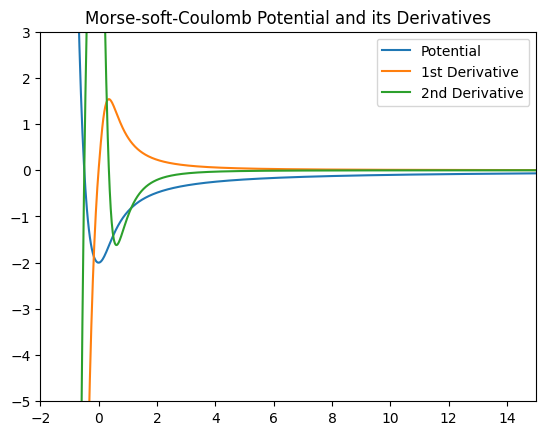

In [8]:
r = np.linspace(-2, 15, 1000)

plt.title(f"{msc.name} Potential and its Derivatives")
plt.plot(r, msc.value(r), label='Potential')
plt.plot(r, msc.first_derivative(r), label='1st Derivative')
plt.plot(r, msc.second_derivative(r), label='2nd Derivative')
plt.xlim(-2, 15)
plt.ylim(-5, 3)
plt.legend()
plt.show()

### `Field` class

We define a field as a callable that returns the (electric) field value at time $t$. We may write a generic field object which interpolates
an array of times with an array of field values, later implementing specific fields with their corresponding parameters and analytical 
expressions:

In [9]:
class Field:
    """
    Basic (electric) field class, given an array of field values and times, calling it results in an
    evaluation of the field (interpolated when necessary) at the specified time
    """

    def __init__(self):
        pass
    
    def __call__(self, times):
        return self.value(times)

    def value(self, times):
        """
        Evaluate the field at `times`
        """

In [10]:
class InterpolatedField(Field):

    def __init__(self, field_times: np.ndarray, field_vals: np.ndarray):
        super().__init__()
        if len(field_times) != len(field_vals):
            raise Warning(f"Time array and field array must be of same size! "
                          f"{len(field_times)} ≠ {len(field_vals)}")

        self.field_times = field_times
        self.field_vals  = field_vals

    def value(self, times):
        """
        Evaluate the field at `times` interpolating `field_vals` and `field_times`
        """
        t = np.asarray(times)
        return np.interp(t, self.field_times, self.field_vals)

In [11]:
class SinusoidField(Field):

    def __init__(self, amplitude: float, ang_frequency: float, phase: float):
        super().__init__()
        self.amplitude     = amplitude
        self.ang_frequency = ang_frequency
        self.phase         = phase

    def value(self, times):
        return self.amplitude*np.sin( self.ang_frequency*times + self.phase )

In [12]:
t = np.linspace(-3, 3, 30)
F = np.sin(t)

In [13]:
fld = InterpolatedField(t, F)

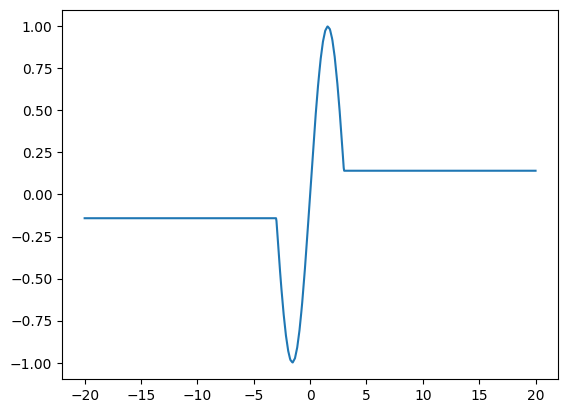

In [14]:
times = np.linspace(-20, 20, 1000)

plt.plot(times, fld(times))

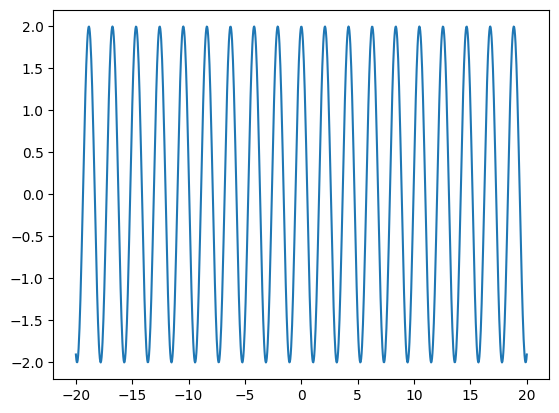

In [15]:
F2 = SinusoidField(2, 3, np.pi/2)

plt.plot(times, F2(times))

## 3. Particle (electron)

In [16]:
class Dynamics:

    def __init__(self, potential: Potential,
                 field: Field = None):

        self.potential = potential
        self.field     = field

    def dstate(self, time: float = 0.0, state: np.ndarray = None):
        r, p = state[..., 0], state[..., 1]
        
        f1 = p
        f2 = -self.potential.first_derivative(r) - self.field(time)
        
        return np.stack([f1, f2], axis=-1)

class StaticDynamics(Dynamics):

    def __init__(self, potential):
        super().__init__(potential)

    def dstate(self, time: float = 0.0, state: np.ndarray = None):
        r, p = state[..., 0], state[..., 1]

        f1 = p
        f2 = -self.potential.first_derivative(r)
        
        return np.stack([f1, f2], axis=-1)

In [16]:
s = np.random.rand(2)


In [84]:
class Trajectory:
    def __init__(self, time, states, potential):
        self.time, self.states, self.potential = time, states, potential

    def for_particle(self, i) -> "Trajectory":
        return Trajectory(self.time, self.states[:, i], self.potential)

    @property
    def position(self):
        return self.states[..., 0]
    
    @property
    def momentum(self):
        return self.states[..., 1]
    
    @property
    def energy(self):
        r, p = self.position, self.momentum
        return p**2 / 2 + self.potential.value(r)   # vectorized, works for N=1 or N=many

    @property
    def action(self):
        E = self.energy
        act = np.vectorize(lambda E: self.potential.action(E))
        return np.where(E < 0, act(E), np.nan)

    


In [24]:
from abc import ABC, abstractmethod


class Integrator(ABC):

    @abstractmethod
    def propagate(self, state0, dynamics, t_span, t_eval): ...


class FixedStepIntegrator(Integrator):
    """Shared substep/output-grid logic. Subclasses only supply the one-step formula."""

    def __init__(self, dt: float):
        self.dt = dt

    def _step(self, dynamics, t, state, h):
        """
        Naivest integrator: forward Euler's method
        """

        return state + dynamics.dstate(t, state) * h


    def propagate(self, dynamics, state0, t_span, t_eval=None):
        t0, tf = t_span
        if t_eval is None:
            t_eval = np.arange(t0, tf, self.dt)      # library-wide default: dt's own grid

        state0 = np.asarray(state0, dtype=float)
        states = np.empty((len(t_eval), *state0.shape))
        t, state = t0, state0

        print(state)

        for j, t_target in enumerate(t_eval):
            while t < t_target:
                h = min(self.dt, t_target - t)         # only the last substep shrinks
                state = self._step(dynamics, t, state, h)
                t += h
            states[j] = state

        return Trajectory(np.asarray(t_eval), states, dynamics.potential)


class RK4Integrator(FixedStepIntegrator):

    def __init__(self, dt = 1.e-4):
        super().__init__(dt)

    def _step(self, dynamics, t, state, h):
        """
        Order 4 Runge-Kutta method for solving differencial equation systems
        """

        k1 = dynamics.dstate(t,         state)
        k2 = dynamics.dstate(t + 0.5*h, state + 0.5*h*k1)
        k3 = dynamics.dstate(t + 0.5*h, state + 0.5*h*k2)
        k4 = dynamics.dstate(t + h,     state + h*k3)
        return state + (h/6)*(k1 + 2*k2 + 2*k3 + k4)

from scipy.integrate import solve_ivp

class ScipyIntegrator(Integrator):
    def __init__(self, method: str = "RK45", **options):
        self.method, self.options = method, options

    def propagate(self, dynamics, state0, t_span, t_eval=None):
        state0 = np.asarray(state0, dtype=float)
        shape = state0.shape                       # (2,) or (N, 2)

        def fun(t, y):
            return np.ravel(dynamics.dstate(t, y.reshape(shape)))

        sol = solve_ivp(fun, t_span, np.ravel(state0),
                         method=self.method, t_eval=t_eval, **self.options)
        states = sol.y.T.reshape(len(sol.t), *shape)
        return Trajectory(sol.t, states, dynamics.potential)

In [49]:
field = SinusoidField(amplitude=0.4, ang_frequency=0.8, phase=0.0)

In [50]:
msc = MorseSoftCoulomb(alpha=0.5)
dyn = Dynamics(msc, field)

prop1 = RK4Integrator(dt=1.e-4)

# traj1 = prop1.propagate(dyn, state0=np.array([1.0, 0.0]), t_span=(0, 100), t_eval=np.linspace(0, 100, 1000))

In [74]:
prop3 = FixedStepIntegrator(dt=1.e-4)

traj3 = prop3.propagate(dyn, state0=np.array([1.0, 0.0]), t_span=(0, 100), t_eval=np.linspace(0, 100, 1000))

[1. 0.]


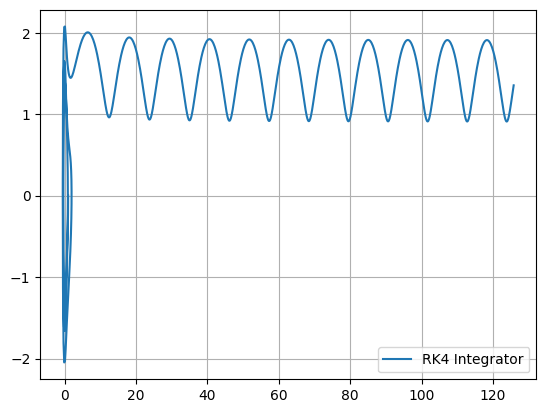

In [23]:
plt.plot(traj1.states[:, 0], traj1.states[:, 1], label='RK4 Integrator')
# plt.plot(traj2.states[:, 0], traj2.states[:, 1], label='Scipy Integrator')
# plt.plot(traj3.states[:, 0], traj3.states[:, 1], label='Fixed Step Integrator')
# plt.plot(traj4.states[:, 0], traj4.states[:, 1], label='DOP853 Integrator')

plt.legend()
plt.grid()
# plt.xlim(10, 16)

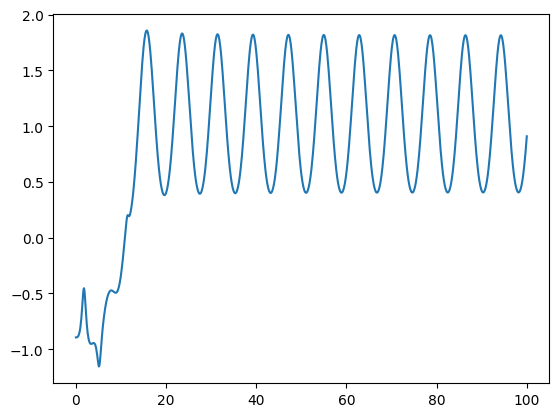

In [83]:
plt.plot(traj1.time, traj1.energy())

In [ ]:
# state0 = np.random.rand(20, 2)

traj_test = prop1.propagate(dyn, state0=state0, t_span=(0, 10), t_eval=np.linspace(0, 10, 1000))

[[0.8603986  0.28709282]
 [0.56029349 0.72409884]
 [0.4729615  0.58365672]
 [0.30066838 0.31198235]
 [0.36276959 0.9864465 ]
 [0.62921688 0.92632704]
 [0.34993966 0.37367219]
 [0.48753941 0.13094853]
 [0.51540104 0.44515312]
 [0.68637574 0.6051633 ]
 [0.69834674 0.19560911]
 [0.4246835  0.76439183]
 [0.13862741 0.06554641]
 [0.11659171 0.69708419]
 [0.65659112 0.22963674]
 [0.08821365 0.23220926]
 [0.58388714 0.57960514]
 [0.5291581  0.12103578]
 [0.13539187 0.62772325]
 [0.60582412 0.69979855]]


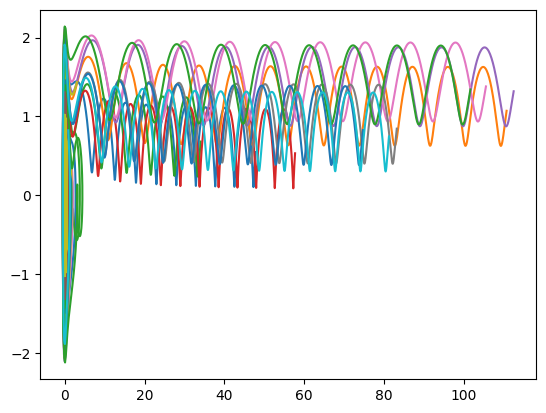

In [29]:
for i in range(20):
    plt.plot(traj4.states[:, i, 0], traj4.states[:, i, 1])

In [51]:
prop2 = ScipyIntegrator(rtol=1.e-6, atol=1.e-9, method="RK45")

state0 = np.random.rand(20, 2)

traj2 = prop2.propagate(dyn, state0=state0, t_span=(0, 100), t_eval=np.linspace(0, 100, 1000))

In [28]:
prop4 = ScipyIntegrator(method="DOP853",
                   rtol=1e-10, atol=1e-12)

traj4 = prop4.propagate(dyn, state0=state0, t_span=(0, 100), t_eval=np.linspace(0, 100, 1000))

In [59]:
class ClassicalParticle:

    def __init__(self, potential: Potential, dynamics: Dynamics,
                 position: float, momentum: float):
        self.potential   = potential
        self.dynamics    = dynamics
        self.position    = position
        self.momentum    = momentum
        self.state       = np.array([position, momentum])

    @property
    def energy(self) -> float:
        """
        Hamiltonian of the particle at a given position and momentum
        """
        return self.potential.energy(self.position, self.momentum)

    # def propagate(self, integrator: Integrator, time: float = 0.0):
    #     """
    #     Propagate the particle's state using the specified integrator
    #     """
    #     self.state = integrator.step(time, self.state)
    #     self.position, self.momentum = self.state

    # def trajectory(self, integrator: Integrator, times: np.ndarray):
    #     """
    #     Propagate the particle's state over a range of times and return the trajectory
    #     """
    #     trajectory = np.zeros((len(times), 2))
    #     for i, t in enumerate(times):
    #         self.propagate(integrator, t)
    #         trajectory[i] = self.state.copy()
    #     return trajectory



In [61]:
class ClassicalSystem:
    def __init__(self, dynamics, states0: np.ndarray, **metadata):
        self.dynamics = dynamics
        self.potential = dynamics.potential
        self.field = dynamics.field
        self.states0 = np.asarray(states0, dtype=float)   # shape (N, 2)
        self.metadata = metadata          # e.g. theta0=..., E0=... — arrays, one entry per particle

    @classmethod
    def from_energy(cls, dynamics, r0s, E, sign=+1, **metadata):
        r0s = np.asarray(r0s, dtype=float)
        p0s = sign * dynamics.potential.momentum(E, r0s)
        return cls(dynamics, np.stack([r0s, p0s], axis=-1), **metadata)

    @property
    def n_particles(self): return self.states0.shape[0]

    def propagate(self, integrator, t_span, t_eval=None) -> Trajectory:
        return integrator.propagate(self.dynamics, self.states0, t_span, t_eval)

In [85]:
syst = ClassicalSystem(dyn, state0)

trajs = syst.propagate(prop2, t_span=(0, 100), t_eval=np.linspace(0, 100, 1000))

In [78]:
action = np.vectorize(MorseSoftCoulomb.action)

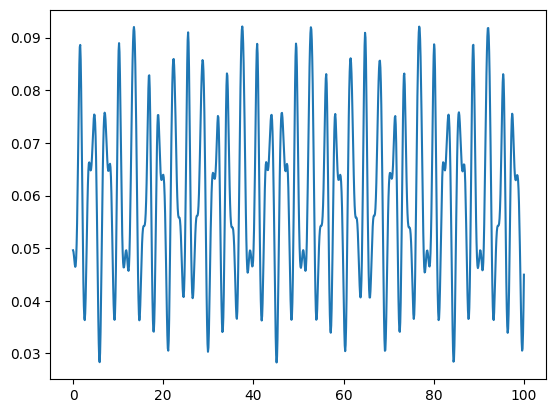

In [86]:
traj_sample = trajs.for_particle(3)
# act = action(traj_sample.energy)
plt.plot(traj_sample.time, traj_sample.action)
# traj_sample.position.shape

In [58]:
trajs.action

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

In [ ]:
msc = MorseSoftCoulomb(alpha=0.1)
dynamics = StaticDynamics(potential=msc)
electron = ClassicalParticle(potential=msc, dynamics=dynamics, position=1.0, momentum=0.0)
integrator = RK4Integrator(dynamics=dynamics, dt=1.e-3)

plt.plot(*electron.trajectory(integrator, np.linspace(0, 100, 10000)).T)
